In [338]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge


In [339]:
df_1 = pd.read_csv('ds/student-mat.csv', sep=';')
df_2 = pd.read_csv('ds/student-por.csv', sep=';')

In [340]:
df_1.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [341]:
df_2.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [342]:
print('df_1:', len(df_1), 'df_2:', len(df_2))

df_1: 395 df_2: 649


In [343]:
df = pd.concat([df_1, df_2])
print(len(df))

1044


In [344]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [345]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'pstatus', 'medu', 'fedu',
       'mjob', 'fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'dalc',
       'walc', 'health', 'absences', 'g1', 'g2', 'g3'],
      dtype='str')


In [346]:
string_columns = list((df.dtypes[df.dtypes == 'str'].index))
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')
df.head()

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,gp,f,18,u,gt3,a,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,gp,f,17,u,gt3,t,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,gp,f,15,u,le3,t,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,gp,f,15,u,gt3,t,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,gp,f,16,u,gt3,t,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [347]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
pstatus       0
medu          0
fedu          0
mjob          0
fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
dalc          0
walc          0
health        0
absences      0
g1            0
g2            0
g3            0
dtype: int64

In [348]:
str_cols = df.select_dtypes(include='str').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

df_dummies = pd.get_dummies(df[str_cols])
X = pd.concat([df[num_cols], df_dummies], axis=1)
del X['g3']
del X['g1']
del X['g2']
y = df['g3']

In [349]:
n = len(df)

n_train = int(0.6 * n)
n_val = int(0.2 * n)
n_test = int(0.2 * n)

df_shuffled = df.iloc[idx]
X_shuffled = X.iloc[idx]
y_shuffled = y.iloc[idx]

y_train = y_shuffled[:n_train]
y_val = y_shuffled[n_train:n_train+n_val]
y_test = y_shuffled[n_train+n_val:]

X_train = X_shuffled[:n_train]
X_val = X_shuffled[n_train:n_train+n_val]
X_test = X_shuffled[n_train+n_val:]


In [350]:
model =  LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [351]:
def rmse(y_pred, y):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [352]:
rmse(y_val, model.predict(X_val))

np.float64(3.808323339234868)

In [353]:
rmse(y_test, model.predict(X_test))

np.float64(3.3371225565017437)

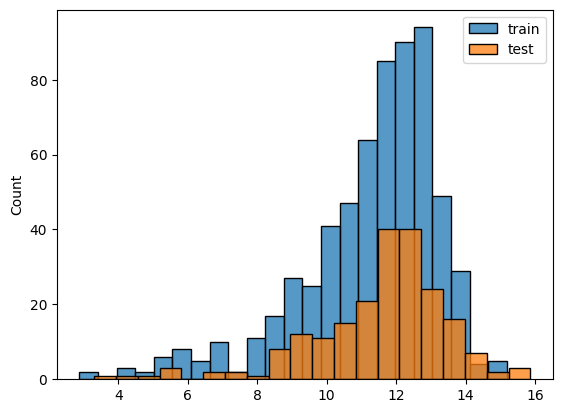

In [354]:
sns.histplot(model.predict(X_train), label='train')
sns.histplot(model.predict(X_test), label='test')
plt.legend()
plt.show()

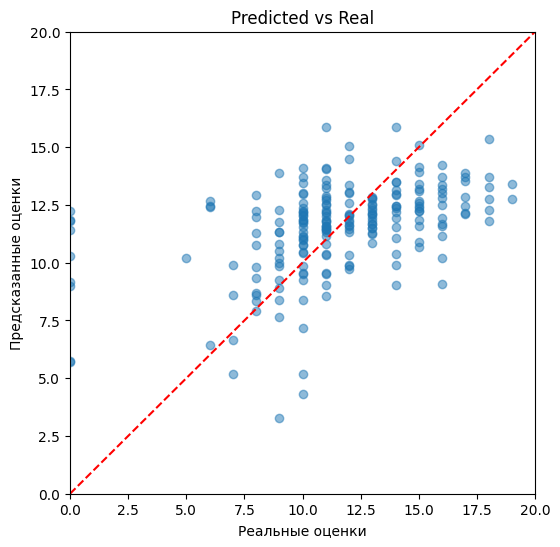

In [355]:
y_pred = model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 20], [0, 20], '--', color='red')
plt.xlabel('Реальные оценки')
plt.ylabel('Предсказанные оценки')
plt.title('Predicted vs Real')
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.show()

In [356]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  2.45
RMSE: 3.34
R²:   0.20


In [357]:
X_train.columns

Index(['age', 'medu', 'fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'dalc', 'walc', 'health', 'absences', 'school_gp',
       'school_ms', 'sex_f', 'sex_m', 'address_r', 'address_u', 'famsize_gt3',
       'famsize_le3', 'pstatus_a', 'pstatus_t', 'mjob_at_home', 'mjob_health',
       'mjob_other', 'mjob_services', 'mjob_teacher', 'fjob_at_home',
       'fjob_health', 'fjob_other', 'fjob_services', 'fjob_teacher',
       'reason_course', 'reason_home', 'reason_other', 'reason_reputation',
       'guardian_father', 'guardian_mother', 'guardian_other', 'schoolsup_no',
       'schoolsup_yes', 'famsup_no', 'famsup_yes', 'paid_no', 'paid_yes',
       'activities_no', 'activities_yes', 'nursery_no', 'nursery_yes',
       'higher_no', 'higher_yes', 'internet_no', 'internet_yes', 'romantic_no',
       'romantic_yes'],
      dtype='str')

In [358]:
# Тест 1

new_student = pd.DataFrame({
    'age': [17],
    'medu': [4],
    'fedu': [3],
    'traveltime': [1],
    'studytime': [3],
    'failures': [0],
    'famrel': [4],
    'freetime': [3],
    'goout': [2],
    'dalc': [1],
    'walc': [1],
    'health': [5],
    'absences': [2],
    'school_gp': [True], 'school_ms': [False],
    'sex_f': [False], 'sex_m': [True],
    'address_r': [False], 'address_u': [True],
    'famsize_gt3': [True], 'famsize_le3': [False],
    'pstatus_a': [False], 'pstatus_t': [True],
    'mjob_at_home': [False], 'mjob_health': [False], 'mjob_other': [False], 'mjob_services': [True], 'mjob_teacher': [False],
    'fjob_at_home': [False], 'fjob_health': [False], 'fjob_other': [True], 'fjob_services': [False], 'fjob_teacher': [False],
    'reason_course': [False], 'reason_home': [True], 'reason_other': [False], 'reason_reputation': [False],
    'guardian_father': [False], 'guardian_mother': [True], 'guardian_other': [False],
    'schoolsup_no': [True], 'schoolsup_yes': [False],
    'famsup_no': [False], 'famsup_yes': [True],
    'paid_no': [True], 'paid_yes': [False],
    'activities_no': [False], 'activities_yes': [True],
    'nursery_no': [False], 'nursery_yes': [True],
    'higher_no': [False], 'higher_yes': [True],
    'internet_no': [False], 'internet_yes': [True],
    'romantic_no': [True], 'romantic_yes': [False],
})

prediction = model.predict(new_student)
print(f"Предсказанная оценка: {prediction[0]:.1f}")

Предсказанная оценка: 13.9


In [359]:
# Тест 2. Берем реального ученика из датасета
real_student = X.iloc[[10]]
real_answer = y.iloc[10]

prediction = model.predict(real_student)

print(f"Реальная оценка: {real_answer}")
print(f"Предсказание:     {prediction[0]:.1f}")
print(f"Ошибка:           {abs(real_answer - prediction[0]):.1f} баллов")

Реальная оценка: 9
Предсказание:     12.5
Ошибка:           3.5 баллов
